# Trader Analysis — v2

This notebook zooms in from "the whole venue" to **one specific wallet** and asks: how did this trader actually do?

We pick a single Polymarket address, pull every fill they were involved in (as either maker or taker), and reconstruct:

- their **inventory** per market (how many YES/NO outcome shares they hold);
- their **cash flows** in USDC;
- a per-market and global **PnL** ("Profit and Loss" — the bottom line);
- an **equity curve** (cumulative cash position over time).

### Pipeline notes

Heavy global aggregations stay SQL-side and reduce to ≤100-row results before crossing the Python boundary, so RAM stays bounded and DuckDB doesn't have to spill 100M-key hash tables to disk. Per-trader slices are tiny and run in Polars.

### Convention (read this once)

Every fill matches a maker order with a taker order. We normalise the messy "who-was-on-which-side" question into:

- `makerAssetId == '0'` → the maker pays USDC and receives outcome shares (we call this **maker-buy**).
- otherwise the maker delivers outcome shares for USDC (**maker-sell**).
- `price = USDC paid / shares received`, bounded `[0, 1]` and readable as a probability.
- `direction` is from **the trader's POV**: `BUY` = they end up holding more shares, `SELL` = fewer. This is what matters for PnL math.

## 1. Setup

Open a DuckDB connection (an in-process SQL engine that streams data off disk so it doesn't have to fit in RAM), point it at the Parquet store, declare a `raw` view that scans all 36 monthly partitions, and confirm we have 151M rows across 36 months. No transformations yet — those come per-trader once we filter.

In [1]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

DATA_GLOB = "../data/orderFilled/**/*.parquet"
assert any(Path("../data/orderFilled").rglob("*.parquet")), (
    "missing parquet data \u2014 run scripts/migrate_orderfilled_xz.py first"
)

con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute("SET threads=4")
con.execute(f"SET temp_directory='{Path('./_duckdb_tmp').resolve().as_posix()}'")

con.execute(
    f"""
    CREATE OR REPLACE VIEW raw AS
    SELECT * FROM read_parquet('{DATA_GLOB}', hive_partitioning=true)
    """
)

con.sql("SELECT count(*) AS rows, count(DISTINCT year || '-' || month) AS months FROM raw").pl()

rows,months
i64,i64
163218046,42


## 3. Pick a trader

A Polymarket "trader" is just a Polygon wallet address — the long `0x...` hex string. Hardcoded addresses below are public Polymarket whales already known to the project's v1 notebook — using them avoids a full top-200 sweep over 151M fills (which would force DuckDB to spill 100k+ trader keys to disk on a 16 GB box). Drop in any address you care about.

The query confirms the trader exists and counts:

- **fills** — total number of fills they appear in.
- **as_maker** — fills where they were the patient side (resting limit order — they posted a price and waited).
- **as_taker** — fills where they were the impatient side (crossing the book — they hit an existing order at market).

The maker/taker split tells you the trader's *style*: high maker-share = market-making behaviour (they earn the spread); high taker-share = directional speculation (they pay the spread to get a position quickly).

In [2]:
USERS = {
    "domah":   "0x9d84ce0306f8551e02efef1680475fc0f1dc1344",
    "50pence": "0x3cf3e8d5427aed066a7a5926980600f6c3cf87b3",
    "fhantom": "0x6356fb47642a028bc09df92023c35a21a0b41885",
    "car":     "0x7c3db723f1d4d8cb9c550095203b686cb11e5c6b",
    "theo4":   "0x56687bf447db6ffa42ffe2204a05edaa20f55839",
    "aenews2": "0x44c1dfe43260c94ed4f1d00de2e1f80fb113ebc1",
}

TARGET = USERS["aenews2"]

exists = con.sql(f"""
    SELECT count(*) AS fills,
           sum(CASE WHEN maker = '{TARGET}' THEN 1 ELSE 0 END) AS as_maker,
           sum(CASE WHEN taker = '{TARGET}' THEN 1 ELSE 0 END) AS as_taker
    FROM raw
    WHERE maker = '{TARGET}' OR taker = '{TARGET}'
""").pl().to_dicts()[0]
print(f"trader: {TARGET}")
print(f"  fills involving them: {exists['fills']:,}")
print(f"  as maker:             {exists['as_maker']:,}")
print(f"  as taker:             {exists['as_taker']:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

trader: 0x44c1dfe43260c94ed4f1d00de2e1f80fb113ebc1
  fills involving them: 62,318
  as maker:             43,090
  as taker:             19,228


## 4. Pull the trader's fills

The `WHERE maker = ... OR taker = ...` predicate gets pushed down into the Parquet scan — DuckDB skips entire row groups that don't contain the target address, so even though the underlying dataset is 150M rows we only physically read the parts that matter. The result table is small enough to bring fully into Polars.

For each fill we compute, **from the trader's perspective**:

- `notional_usdc` / `shares` — size of the trade in dollars and outcome shares.
- `price` — implied probability (`notional / shares`), bounded [0, 1].
- `direction` — `BUY` if the trader ends up with more shares after this fill, `SELL` if fewer. (The CASE WHEN statements unscramble who was on which side: a maker-buy by us is a buy; a maker-buy by our counterparty is a sell from our POV; etc.)
- `share_delta` — signed change in share inventory (positive on a buy, negative on a sell).
- `cash_delta` — signed change in USDC balance (negative on a buy: they paid; positive on a sell: they received).

`share_delta` and `cash_delta` are the two columns we accumulate to compute PnL.

In [3]:
trader_fills = con.sql(f"""
    WITH base AS (
      SELECT
        to_timestamp("timestamp")::TIMESTAMP AS ts,
        transactionHash, id,
        maker, taker,
        CASE WHEN makerAssetId = '0' THEN makerAmountFilled ELSE takerAmountFilled END / 1e6 AS notional_usdc,
        CASE WHEN makerAssetId = '0' THEN takerAmountFilled ELSE makerAmountFilled END / 1e6 AS shares,
        CASE WHEN makerAssetId = '0' THEN takerAssetId ELSE makerAssetId END AS ctf_id,
        CASE WHEN makerAssetId = '0' THEN 'buy' ELSE 'sell' END AS maker_side
      FROM raw
      WHERE maker = '{TARGET}' OR taker = '{TARGET}'
    )
    SELECT ts, transactionHash, id, ctf_id, notional_usdc, shares,
           CASE WHEN shares > 0 THEN notional_usdc / shares END AS price,
           CASE
             WHEN maker = '{TARGET}' AND maker_side = 'buy'  THEN 'BUY'
             WHEN maker = '{TARGET}' AND maker_side = 'sell' THEN 'SELL'
             WHEN taker = '{TARGET}' AND maker_side = 'buy'  THEN 'SELL'
             ELSE 'BUY'
           END AS direction,
           CASE
             WHEN maker = '{TARGET}' AND maker_side = 'buy'  THEN  shares
             WHEN maker = '{TARGET}' AND maker_side = 'sell' THEN -shares
             WHEN taker = '{TARGET}' AND maker_side = 'buy'  THEN -shares
             ELSE shares
           END AS share_delta,
           CASE
             WHEN maker = '{TARGET}' AND maker_side = 'buy'  THEN -notional_usdc
             WHEN maker = '{TARGET}' AND maker_side = 'sell' THEN  notional_usdc
             WHEN taker = '{TARGET}' AND maker_side = 'buy'  THEN  notional_usdc
             ELSE -notional_usdc
           END AS cash_delta
    FROM base
    ORDER BY ts
""").pl()
print(f"trader fills: {trader_fills.height:,}")
trader_fills.head(5)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

trader fills: 62,318


ts,transactionHash,id,ctf_id,notional_usdc,shares,price,direction,share_delta,cash_delta
datetime[μs],str,str,str,f64,f64,f64,str,f64,f64
2024-01-14 01:34:58,"""0xb6f17d40ec98092538704fdfd379…","""legacy:381822""","""749931077283900093982746081810…",5898.8528,36867.83,0.16,"""BUY""",36867.83,-5898.8528
2024-01-14 01:34:58,"""0xb6f17d40ec98092538704fdfd379…","""legacy:381823""","""749931077283900093982746081810…",5898.8528,36867.83,0.16,"""BUY""",36867.83,-5898.8528
2024-01-14 05:56:14,"""0xaf3c69d391120e258f92ef9ccb83…","""legacy:382691""","""749931077283900093982746081810…",100.7097,592.41,0.17,"""SELL""",-592.41,100.7097
2024-01-14 11:19:24,"""0xbdd9fe80640f7996e61ac6cbab5d…","""legacy:383262""","""607828384053331866607152181337…",760.0,800.0,0.95,"""BUY""",800.0,-760.0
2024-01-14 11:21:12,"""0xffd20a7234e612cad3320a4b939b…","""legacy:383264""","""607828384053331866607152181337…",228.0,240.0,0.95,"""BUY""",240.0,-228.0


## 5. Per-market PnL

PnL = "Profit and Loss". We split it into two pieces, computed *per outcome the trader touched*:

- **cash_pnl** — sum of cash deltas per `ctf_id`. Positive means the trader has *taken USDC out of this market net* (sold more dollar-value than they bought); negative means they're net long, having put USDC in.
- **inventory** — net shares still held in this outcome (`buys − sells`).
- **mark** — last observed fill price for that `ctf_id` in the trader's own slice (avoiding a global scan); clipped to {0, 1} when in the ≥ 0.98 / ≤ 0.02 zone, since markets that drift to the extremes have effectively resolved (favourites print at $1, losers at $0).
- **unrealized** — `inventory × mark`. The dollar value of the shares still on the books at current price.
- **total_pnl = cash_pnl + unrealized** — the headline number.

**Reading the table:** a profitable position usually shows up as either:
- *negative cash_pnl + large positive unrealized* — they paid USDC for shares that are now worth more (an unclosed winner), or
- *positive cash_pnl + zero/negative unrealized* — they sold their shares while still up (a realised winner).

Caveat: real `redemption` events (the venue paying out $1 per winning share at market resolution) live in the v2 `trades` table after `poly-data process`. The 0.98/0.02 clamp is a proxy that catches the clean cases.

In [4]:
marks = (
    trader_fills.filter(pl.col("price").is_finite() & (pl.col("shares") > 0))
    .sort("ts")
    .group_by("ctf_id")
    .agg(pl.col("price").last().alias("last_price"))
    .with_columns(
        pl.when(pl.col("last_price") > 0.98).then(1.0)
          .when(pl.col("last_price") < 0.02).then(0.0)
          .otherwise(pl.col("last_price"))
          .alias("mark")
    )
    .select("ctf_id", "mark")
)
print(f"unique markets traded: {marks.height:,}")
marks.head()

unique markets traded: 3,297


ctf_id,mark
str,f64
"""102638179462273139591451128325…",1.0
"""105389713691966638674332959332…",0.216
"""725248073340660012694963302450…",0.893
"""128713922374807379014507173200…",0.0
"""101490910324419498943088475882…",1.0


In [5]:
pnl = (
    trader_fills.group_by("ctf_id")
    .agg(
        pl.col("cash_delta").sum().alias("cash_pnl"),
        pl.col("share_delta").sum().alias("inventory"),
        (pl.col("direction") == "BUY").sum().alias("buys"),
        (pl.col("direction") == "SELL").sum().alias("sells"),
        pl.col("notional_usdc").sum().alias("gross_notional"),
    )
    .join(marks, on="ctf_id", how="left")
    .with_columns((pl.col("inventory") * pl.col("mark")).alias("unrealized"))
    .with_columns((pl.col("cash_pnl") + pl.col("unrealized")).alias("total_pnl"))
    .sort("total_pnl", descending=True)
)

totals = pnl.select(
    pl.col("cash_pnl").sum().alias("cash_pnl"),
    pl.col("unrealized").sum().alias("unrealized"),
    pl.col("total_pnl").sum().alias("total_pnl"),
    pl.col("gross_notional").sum().alias("gross_notional"),
).to_dicts()[0]
print(f"cash PnL:        ${totals['cash_pnl']:>14,.2f}")
print(f"unrealized:      ${totals['unrealized']:>14,.2f}")
print(f"total PnL:       ${totals['total_pnl']:>14,.2f}")
print(f"gross notional:  ${totals['gross_notional']:>14,.2f}")
if totals['gross_notional'] > 0:
    print(f"return on flow:  {totals['total_pnl'] / totals['gross_notional']:.2%}")

with pl.Config(fmt_str_lengths=24, tbl_rows=15):
    print(pnl.head(15))

cash PnL:        $-44,699,269.09
unrealized:      $ 45,711,864.37
total PnL:       $  1,012,595.27
gross notional:  $104,698,583.86
return on flow:  0.97%
shape: (15, 9)
┌────────────┬────────────┬────────────┬──────┬───┬────────────┬──────────┬────────────┬───────────┐
│ ctf_id     ┆ cash_pnl   ┆ inventory  ┆ buys ┆ … ┆ gross_noti ┆ mark     ┆ unrealized ┆ total_pnl │
│ ---        ┆ ---        ┆ ---        ┆ ---  ┆   ┆ onal       ┆ ---      ┆ ---        ┆ ---       │
│ str        ┆ f64        ┆ f64        ┆ u32  ┆   ┆ ---        ┆ f64      ┆ f64        ┆ f64       │
│            ┆            ┆            ┆      ┆   ┆ f64        ┆          ┆            ┆           │
╞════════════╪════════════╪════════════╪══════╪═══╪════════════╪══════════╪════════════╪═══════════╡
│ 7030878456 ┆ -200260.36 ┆ 436514.795 ┆ 66   ┆ … ┆ 762469.910 ┆ 1.0      ┆ 436514.795 ┆ 236254.42 │
│ 1714015174 ┆ 7483       ┆ 547        ┆      ┆   ┆ 283        ┆          ┆ 547        ┆ 8064      │
│ 8423…      ┆        

## 6. Equity curve (cash-only)

Plots **cumulative USDC** flowing into and out of the trader's wallet from fills, sorted by time. This is the literal stream — a fill that costs $5,000 drops the curve $5,000; a fill that yields $5,000 lifts it $5,000.

Inventory mark-to-market is **deliberately excluded** from this view: when a trader is in a profitable but unrealised position, the cash curve will be deeply negative (they paid for the shares) even though their *total* PnL is positive. This is why traders track "cash equity" and "total equity" as separate lines — one tells you about real liquidity, the other tells you about paper performance.

Green shading = above zero (net cash positive — they've taken more USDC out than they've put in); red = below zero (net cash negative — they're carrying open exposure paid for in cash).

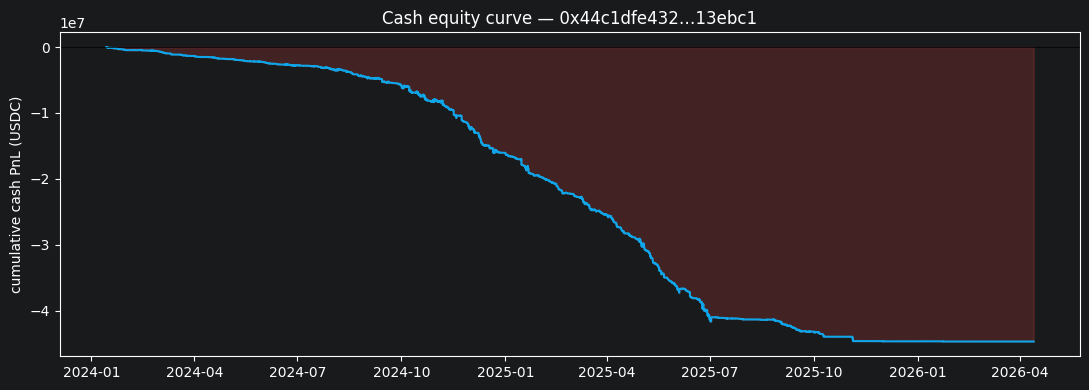

In [6]:
curve = trader_fills.sort("ts").with_columns(
    pl.col("cash_delta").cum_sum().alias("cum_cash")
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(curve["ts"], curve["cum_cash"], color="#0ea5e9")
ax.fill_between(curve["ts"], 0, curve["cum_cash"],
                where=curve["cum_cash"] >= 0, color="#22c55e", alpha=0.2)
ax.fill_between(curve["ts"], 0, curve["cum_cash"],
                where=curve["cum_cash"] < 0, color="#ef4444", alpha=0.2)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("cumulative cash PnL (USDC)")
ax.set_title(f"Cash equity curve \u2014 {TARGET[:12]}\u2026{TARGET[-6:]}")
plt.tight_layout()
plt.show()

## 7. Trade-size and direction profile

Two diagnostic pictures of how the trader actually behaves:

- **size stats** — average, median, 95th-percentile and max fill size, in USDC. The gap between mean and median tells you how often they print outsized trades.
- **by direction** — total fills, total notional, and average traded price split into BUYs vs. SELLs. If `avg_price` is materially **lower for BUYs than SELLs**, the trader is buying cheap and selling rich on average — the desired pattern, an empirical edge.
- **trade-size histogram** (left chart) — log-scale x-axis (so each bar represents a 10× wider dollar range); shows whether they're a constant-sizer or have a fat tail of big bets.
- **prices traded** (right chart) — distribution of implied prices on their fills. Heavy mass near 0.5 = they trade uncertain markets; near 0/1 = they trade favourites or underdogs (a different style with very different risk profile).

      avg_size: $    1,680.07
   median_size: $       43.43
      p95_size: $    6,603.99
      max_size: $  466,996.31

by direction:
shape: (2, 4)
┌───────────┬───────┬──────────┬───────────┐
│ direction ┆ fills ┆ notional ┆ avg_price │
│ ---       ┆ ---   ┆ ---      ┆ ---       │
│ str       ┆ u32   ┆ f64      ┆ f64       │
╞═══════════╪═══════╪══════════╪═══════════╡
│ BUY       ┆ 35720 ┆ 7.4699e7 ┆ 0.577996  │
│ SELL      ┆ 26598 ┆ 3.0000e7 ┆ 0.392965  │
└───────────┴───────┴──────────┴───────────┘


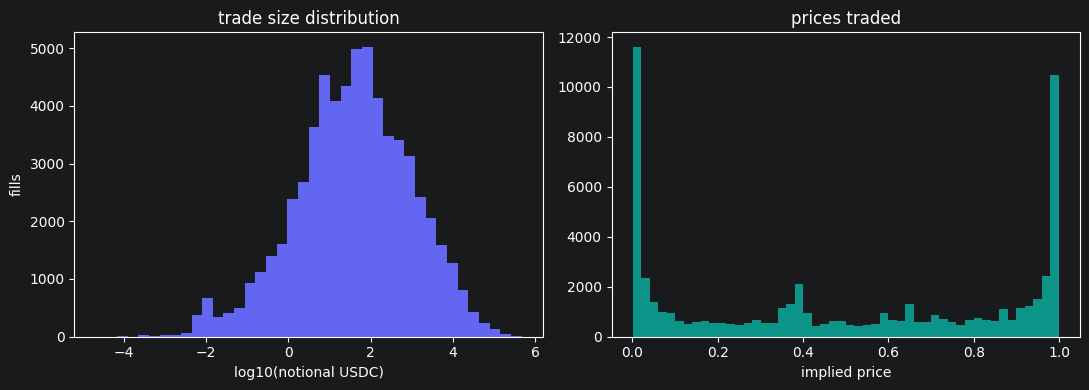

In [7]:
size_stats = trader_fills.select(
    pl.col("notional_usdc").mean().alias("avg_size"),
    pl.col("notional_usdc").median().alias("median_size"),
    pl.col("notional_usdc").quantile(0.95).alias("p95_size"),
    pl.col("notional_usdc").max().alias("max_size"),
).to_dicts()[0]
for k, v in size_stats.items():
    print(f"  {k:>12}: ${v:>12,.2f}")

by_dir = trader_fills.group_by("direction").agg(
    pl.len().alias("fills"),
    pl.col("notional_usdc").sum().alias("notional"),
    pl.col("price").mean().alias("avg_price"),
).sort("direction")
print("\nby direction:")
print(by_dir)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
log_sizes = np.log10(trader_fills["notional_usdc"].to_numpy() + 1e-6)
axes[0].hist(log_sizes, bins=40, color="#6366f1")
axes[0].set_xlabel("log10(notional USDC)")
axes[0].set_ylabel("fills")
axes[0].set_title("trade size distribution")

prices = trader_fills.filter(
    pl.col("price").is_finite() & (pl.col("price") >= 0) & (pl.col("price") <= 1)
)["price"].to_numpy()
axes[1].hist(prices, bins=50, color="#0d9488")
axes[1].set_xlabel("implied price")
axes[1].set_title("prices traded")
plt.tight_layout()
plt.show()

## Notes

- **`redemption` events** (the venue paying out $1 per winning share when a market resolves) aren't in `orderFilled`. PnL on resolved markets uses the last-observed-price clamp (≥ 0.98 → 1, ≤ 0.02 → 0). For exact resolution PnL, run `poly-data process` and join `data/trades`.
- **Joining `ctf_id` against `data/markets`** reveals the human-readable question and `token1`/`token2` outcome labels. Without that join, the per-market PnL table shows raw 256-bit token ids.
- The `trader_fills` table is per-trader, so the PnL math doesn't have to deduplicate — each on-chain fill yields exactly one row from the trader's POV (we already disambiguated the maker/taker side earlier).